In [ ]:
#sfrom google.colab import drive
##drive.mount('/content/drive')

In [ ]:
# ============================================================
# CELL 1: Install and imports
# ============================================================
# !pip install -q pandas numpy scikit-learn matplotlib seaborn joblib

import os
import json
import warnings
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")

BASE_PATH   = Path("/content/drive/Othercomputers/My PC/data_u")   # CHANGE THIS
OUTPUT_PATH = Path("/content/drive/MyDrive/IntelliSense/ml_outputs")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
MODEL_PATH  = OUTPUT_PATH / "isolation_forest_models"
MODEL_PATH.mkdir(exist_ok=True)

print("✅ Imports loaded")


✅ Imports loaded


In [ ]:
# ============================================================
# CELL 2: Load companies_financial_scenarios
# ============================================================
fin_csv = BASE_PATH / "structured" / "companies_financial_scenarios.csv"
fin_df  = pd.read_csv(fin_csv)

print(f"📊 Loaded companies_financial_scenarios: {fin_df.shape}")
print(f"   Columns: {list(fin_df.columns)}")
print(f"   Sectors: {fin_df['sector'].value_counts().to_dict() if 'sector' in fin_df.columns else 'sector col missing'}")

# Also load ALM features (adds liquidity ratios)
alm_csv = BASE_PATH / "alm" / "alm_features.csv"
alm_df  = pd.read_csv(alm_csv) if alm_csv.exists() else pd.DataFrame()
print(f"   ALM rows loaded: {len(alm_df)}")

# Load portfolio performance for NBFCs
port_csv = BASE_PATH / "structured" / "portfolio_performance.csv"
port_df  = pd.read_csv(port_csv) if port_csv.exists() else pd.DataFrame()
print(f"   Portfolio rows loaded: {len(port_df)}")


📊 Loaded companies_financial_scenarios: (2238, 22)
   Columns: ['SYMBOL', 'NAME OF COMPANY', 'SERIES', 'DATE OF LISTING', 'PAID UP VALUE', 'MARKET LOT', 'ISIN NUMBER', 'FACE VALUE', 'sector', 'project_sector', 'company_id', 'case_id', 'gstin', 'revenue_cr', 'profit_cr', 'debt_cr', 'equity_cr', 'interest_expense_cr', 'scenario_type', 'trend_type', 'company_cin', 'pan']
   Sectors: {'Industrials': 462, 'Consumer Cyclical': 431, 'Basic Materials': 370, 'Financial Services': 236, 'Technology': 180, 'Healthcare': 162, 'Consumer Defensive': 160, 'Real Estate': 82, 'Communication Services': 76, 'Utilities': 42, 'Energy': 37}
   ALM rows loaded: 435
   Portfolio rows loaded: 1652


In [ ]:
# ============================================================
# CELL 3: Derive financial ratios from raw columns
# ============================================================

r = fin_df.copy()

revenue      = r["revenue_cr"].astype(float)
profit       = r["profit_cr"].astype(float)
debt         = r["debt_cr"].astype(float)
equity       = r["equity_cr"].astype(float)
interest_exp = r["interest_expense_cr"].astype(float)

# Sector-aware depreciation assumption (Issue 1 fix)
DEPRECIATION_BY_SECTOR = {
    "Basic Materials"       : 0.08,
    "Industrials"           : 0.10,
    "Energy"                : 0.12,
    "Utilities"             : 0.15,
    "Healthcare"            : 0.07,
    "Technology"            : 0.04,
    "Financial Services"    : 0.02,
    "Consumer Cyclical"     : 0.06,
    "Consumer Defensive"    : 0.06,
    "Real Estate"           : 0.10,
    "Communication Services": 0.05,
}
DEFAULT_DEPRECIATION = 0.07

dep_pct  = r["sector"].map(DEPRECIATION_BY_SECTOR).fillna(DEFAULT_DEPRECIATION)
depr_est = revenue * dep_pct

ebitda    = profit + interest_exp + depr_est
annual_ds = interest_exp + (debt * 0.10)

fin_df["dscr"]              = (ebitda / annual_ds.replace(0, np.nan)).round(4)
fin_df["debt_to_equity"]    = (debt / equity.replace(0, np.nan)).round(4)
fin_df["interest_coverage"] = ((profit + interest_exp) / interest_exp.replace(0, np.nan)).round(4)
fin_df["ebitda_margin"]     = (ebitda / revenue.replace(0, np.nan) * 100).round(4)
fin_df["pat_margin"]        = (profit / revenue.replace(0, np.nan) * 100).round(4)
fin_df["revenue_cagr"]      = np.nan
fin_df["alm_short_term_gap_pct"] = np.nan

# Issue 3 fix — define ratio_lookup here so Cell 5 can use it
ratio_lookup = fin_df.set_index("case_id")

print("✅ Ratios computed with sector-aware depreciation")
print(fin_df[["company_id", "sector", "dscr", "debt_to_equity", "ebitda_margin", "pat_margin"]].head(5).to_string())

✅ Ratios computed with sector-aware depreciation
   company_id              sector    dscr  debt_to_equity  ebitda_margin  pat_margin
0  COMP_00001     Basic Materials  3.8252          0.5625        28.9109     17.8305
1  COMP_00002  Financial Services  1.2008          1.5000        13.4176     10.0405
2  COMP_00003  Financial Services  1.8825          1.5000        13.9301     11.2190
3  COMP_00004          Technology  3.2567          0.4603        24.7055     16.7453
4  COMP_00005         Industrials  2.6524          1.1263        26.3118     11.3167


In [ ]:
# ============================================================
# CELL 4: Isolation Forest — Train one model per sector
# ============================================================

# Feature set for Isolation Forest
FEATURES_ALL  = ["dscr", "debt_to_equity", "interest_coverage", "ebitda_margin", "pat_margin"]
FEATURES_NBFC = FEATURES_ALL + ["gross_npa_pct", "net_npa_pct", "pcr"]

SECTORS = fin_df["sector"].dropna().unique() if "sector" in fin_df.columns else []
print(f"\n🏭 Sectors to train: {SECTORS}")

sector_models   = {}   # sector → {model, scaler, imputer, features}
anomaly_results = []

for sector in SECTORS:
    sector_data = fin_df[fin_df["sector"] == sector].copy()
    n           = len(sector_data)

    if n < 10:
        print(f"  ⚠️  {sector}: only {n} companies — skipping (need ≥10)")
        continue

    features = FEATURES_NBFC if sector == "NBFC" else FEATURES_ALL
    features = [f for f in features if f in sector_data.columns]
    X        = sector_data[features].copy()

    # Impute missing values with median (robust for financial ratios)
    imputer = SimpleImputer(strategy="median")
    X_imp   = imputer.fit_transform(X)

    # Scale (RobustScaler handles outliers in financial data better than StandardScaler)
    scaler  = RobustScaler()
    X_scaled= scaler.fit_transform(X_imp)

    # Train Isolation Forest
    # contamination=0.10 → expect ~10% of companies to be anomalous (conservative)
    n_estimators = 200 if n > 100 else 100
    iso = IsolationForest(
        n_estimators  = n_estimators,
        contamination = 0.10,
        random_state  = 42,
        n_jobs        = -1,
    )
    iso.fit(X_scaled)

    # Score all companies in this sector
    raw_scores   = iso.score_samples(X_scaled)   # more negative = more anomalous
    predictions  = iso.predict(X_scaled)          # -1 = outlier, 1 = normal

    # Normalise to 0-1 (0 = most anomalous, 1 = most normal)
    norm_scores  = (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min() + 1e-9)

    # Classify
    def classify_anomaly(score, pred):
        if pred == -1 and score < 0.20: return "extreme_outlier"
        if pred == -1:                  return "anomalous"
        return "normal"

    for i, (idx, row) in enumerate(sector_data.iterrows()):
        anom_class = classify_anomaly(float(norm_scores[i]), int(predictions[i]))

        # Per-feature percentile rank within sector (for benchmark narratives)
        feature_percentiles = {}
        for fi, feat in enumerate(features):
            col_vals = X_imp[:, fi]
            val      = X_imp[i, fi]
            pct_rank = float(np.mean(col_vals <= val) * 100)
            feature_percentiles[feat] = round(pct_rank, 1)

        anomaly_results.append({
            "case_id"                  : row.get("case_id"),
            "company_id"               : row.get("company_id"),
            "company_cin"              : row.get("company_cin"),
            "sector"                   : sector,
            "anomaly_score_raw"        : round(float(raw_scores[i]), 6),
            "anomaly_score_normalized" : round(float(norm_scores[i]), 4),
            "isolation_forest_label"   : "outlier" if predictions[i] == -1 else "normal",
            "anomaly_classification"   : anom_class,
            "feature_percentile_ranks" : json.dumps(feature_percentiles),
            "n_sector_peers"           : n,
            "model_n_estimators"       : n_estimators,
            "processed_timestamp"      : datetime.utcnow().isoformat(),
        })

    # Save model + preprocessors
    sector_models[sector] = {
        "model": iso, "scaler": scaler,
        "imputer": imputer, "features": features
    }
    joblib.dump(
        {"model": iso, "scaler": scaler, "imputer": imputer, "features": features},
        MODEL_PATH / f"iso_forest_{sector.lower()}.pkl"
    )

    outlier_count = sum(1 for r in anomaly_results[-n:] if r["isolation_forest_label"] == "outlier")
    print(f"  ✅ {sector:20s} | n={n:4d} | outliers={outlier_count:3d} | "
          f"features={len(features)}")

iso_df = pd.DataFrame(anomaly_results)
iso_out = OUTPUT_PATH / "isolation_forest_scores.csv"
iso_df.to_csv(iso_out, index=False)
print(f"\n💾 Saved: {iso_out}  ({len(iso_df)} rows)")



🏭 Sectors to train: ['Basic Materials' 'Financial Services' 'Technology' 'Industrials'
 'Energy' 'Healthcare' 'Consumer Cyclical' 'Consumer Defensive'
 'Real Estate' 'Utilities' 'Communication Services']
  ✅ Basic Materials      | n= 370 | outliers= 37 | features=5
  ✅ Financial Services   | n= 236 | outliers= 24 | features=5
  ✅ Technology           | n= 180 | outliers= 18 | features=5
  ✅ Industrials          | n= 462 | outliers= 47 | features=5
  ✅ Energy               | n=  37 | outliers=  4 | features=5
  ✅ Healthcare           | n= 162 | outliers= 17 | features=5
  ✅ Consumer Cyclical    | n= 431 | outliers= 43 | features=5
  ✅ Consumer Defensive   | n= 160 | outliers= 16 | features=5
  ✅ Real Estate          | n=  82 | outliers=  9 | features=5
  ✅ Utilities            | n=  42 | outliers=  5 | features=5
  ✅ Communication Services | n=  76 | outliers=  8 | features=5

💾 Saved: /content/drive/MyDrive/IntelliSense/ml_outputs/isolation_forest_scores.csv  (2238 rows)


In [ ]:
# ============================================================
# CELL 5: Generate peer benchmark narratives (FIXED)
# ============================================================

RATIO_LABELS = {
    "dscr"              : ("DSCR", "x", "higher is better"),
    "debt_to_equity"    : ("Debt/Equity", "x", "lower is better"),
    "interest_coverage" : ("Interest Coverage", "x", "higher is better"),
    "ebitda_margin"     : ("EBITDA Margin", "%", "higher is better"),
    "pat_margin"        : ("PAT Margin", "%", "higher is better"),
    "gross_npa_pct"     : ("Gross NPA", "%", "lower is better"),
    "net_npa_pct"       : ("Net NPA", "%", "lower is better"),
}

benchmark_rows = []

for _, iso_row in iso_df.iterrows():
    case_id    = iso_row["case_id"]
    company_id = iso_row["company_id"]
    sector     = iso_row["sector"]
    peers      = iso_row["n_sector_peers"]

    # Parse percentile ranks from JSON string
    try:
        percentiles = json.loads(iso_row["feature_percentile_ranks"])
    except:
        continue

    # Get actual ratio values — ratio_lookup is indexed by case_id
    ratio_row = ratio_lookup.loc[case_id] if case_id in ratio_lookup.index else None

    for feat, pct_rank in percentiles.items():
        if feat not in RATIO_LABELS:
            continue

        label, unit, direction = RATIO_LABELS[feat]

        # Get actual value from ratio_lookup
        actual_val = np.nan
        if ratio_row is not None and feat in ratio_row.index:
            actual_val = ratio_row[feat]

        # Fallback: get from fin_df directly using company_id
        if pd.isna(actual_val) and company_id in fin_df["company_id"].values:
            fin_row    = fin_df[fin_df["company_id"] == company_id].iloc[0]
            actual_val = fin_row.get(feat, np.nan) if feat in fin_row.index else np.nan

        if pd.isna(actual_val):
            continue

        pct_rank = float(pct_rank)

        if pct_rank >= 75:
            bucket_label = f"top {100-pct_rank:.0f}th percentile"
            bucket = "top_quartile"
        elif pct_rank >= 50:
            bucket_label = f"{pct_rank:.0f}th percentile"
            bucket = "above_median"
        elif pct_rank >= 25:
            bucket_label = f"{pct_rank:.0f}th percentile"
            bucket = "below_median"
        else:
            bucket_label = f"bottom {pct_rank:.0f}th percentile"
            bucket = "bottom_quartile"

        is_risk = (
            (direction == "higher is better" and pct_rank < 25) or
            (direction == "lower is better"  and pct_rank > 75)
        )

        narrative = (
            f"{label} of {actual_val:.2f}{unit} is at the {bucket_label} "
            f"among {peers} {sector} sector peers."
        )
        if is_risk:
            narrative += f" ⚠️ Risk signal ({direction})."

        benchmark_rows.append({
            "case_id"           : case_id,
            "company_id"        : company_id,
            "sector"            : sector,
            "ratio_name"        : feat,
            "ratio_label"       : label,
            "actual_value"      : round(float(actual_val), 4),
            "unit"              : unit,
            "percentile_rank"   : pct_rank,
            "percentile_bucket" : bucket,
            "direction"         : direction,
            "is_risk_signal"    : is_risk,
            "narrative"         : narrative,
            "feeds_into_c"      : (
                "Capacity" if feat in ["dscr", "interest_coverage", "ebitda_margin",
                                       "pat_margin", "gross_npa_pct", "net_npa_pct"]
                else "Capital" if feat == "debt_to_equity"
                else "Conditions"
            ),
        })

bench_df  = pd.DataFrame(benchmark_rows)
bench_out = OUTPUT_PATH / "peer_benchmark_narratives.csv"
bench_df.to_csv(bench_out, index=False)
print(f"✅ Benchmark narratives: {len(bench_df)} rows, {bench_df['company_id'].nunique()} companies")
print(f"💾 Saved: {bench_out}")
print(f"\nSample:")
print(bench_df.head(3)[["company_id", "ratio_label", "actual_value", "percentile_rank", "narrative"]].to_string())

✅ Benchmark narratives: 11190 rows, 2238 companies
💾 Saved: /content/drive/MyDrive/IntelliSense/ml_outputs/peer_benchmark_narratives.csv

Sample:
   company_id        ratio_label  actual_value  percentile_rank                                                                                         narrative
0  COMP_00001               DSCR        3.8252             83.0               DSCR of 3.83x is at the top 17th percentile among 370 Basic Materials sector peers.
1  COMP_00001        Debt/Equity        0.5625             19.7     Debt/Equity of 0.56x is at the bottom 20th percentile among 370 Basic Materials sector peers.
2  COMP_00001  Interest Coverage        6.7882             90.5  Interest Coverage of 6.79x is at the top 10th percentile among 370 Basic Materials sector peers.


In [ ]:
# Find Ugro in the data
print(fin_df[fin_df["NAME OF COMPANY"].str.contains("Ugro", case=False, na=False)][["company_id", "company_cin", "NAME OF COMPANY"]])

# If not found, pick the most interesting NBFC/Financial Services case instead
print("\nFinancial Services companies sample:")
print(fin_df[fin_df["sector"] == "Financial Services"][["company_id", "company_cin", "NAME OF COMPANY"]].head(10).to_string())

      company_id            company_cin       NAME OF COMPANY
2078  COMP_02079  L86097MN2010PLC002079  Ugro Capital Limited

Financial Services companies sample:
    company_id            company_cin                             NAME OF COMPANY
1   COMP_00002  L74195MZ2010PLC000002    21st Century Management Services Limited
2   COMP_00003  L11613DN2010PLC000003                         360 ONE WAM LIMITED
5   COMP_00006  L87095OR2010PLC000006                      5Paisa Capital Limited
9   COMP_00010  L35060TR2010PLC000010              Aadhar Housing Finance Limited
19  COMP_00020  L90990AS2010PLC000020                    Aavas Financiers Limited
23  COMP_00024  L13834KL2010PLC000024                Aditya Birla Capital Limited
31  COMP_00032  L17870ML2010PLC000032           Aditya Birla Sun Life AMC Limited
66  COMP_00067  L23099JH2010PLC000067               Akme Fintrade (India) Limited
67  COMP_00068  L24320AN2010PLC000068            Abans Financial Services Limited
80  COMP_00081  L7

In [ ]:
# ============================================================
# CELL 6: Ugro Capital spot-check
# ============================================================
print("\n" + "="*60)
print("UGRO CAPITAL ISOLATION FOREST SPOT-CHECK")
print("="*60)

ugro_iso = iso_df[iso_df["company_id"].str.upper().str.contains("UGRO", na=False)]
ugro_rat = ratio_df[ratio_df["company_id"].str.upper().str.contains("UGRO", na=False)]
ugro_ben = bench_df[bench_df["company_id"].str.upper().str.contains("UGRO", na=False)]

if ugro_iso.empty:
    print("  ⚠️  Ugro not found by company_id. Checking company_cin...")
    ugro_iso = iso_df[iso_df["company_cin"].str.upper().str.contains("UGRO", na=False)]

if not ugro_iso.empty:
    row = ugro_iso.iloc[0]
    print(f"  Company       : {row['company_id']}")
    print(f"  Sector        : {row['sector']}")
    print(f"  Anomaly Class : {row['anomaly_classification'].upper()}")
    print(f"  Anomaly Score : {row['anomaly_score_normalized']:.4f}  (0=anomalous, 1=normal)")
    print(f"\n  Computed Ratios:")
    if not ugro_rat.empty:
        for col in ["dscr", "debt_to_equity", "interest_coverage",
                    "ebitda_margin", "pat_margin", "gross_npa_pct"]:
            if col in ugro_rat.columns:
                print(f"    {col:25s}: {ugro_rat.iloc[0][col]:.3f}")
    print(f"\n  Peer Benchmark Narratives:")
    for _, bench_row in ugro_ben.iterrows():
        prefix = "  ⚠️ " if bench_row["is_risk_signal"] else "  ✅ "
        print(f"{prefix}{bench_row['narrative']}")
else:
    print("  Ugro Capital not found. Check company_id in companies_financial_scenarios.csv")



UGRO CAPITAL ISOLATION FOREST SPOT-CHECK
  ⚠️  Ugro not found by company_id. Checking company_cin...
  Ugro Capital not found. Check company_id in companies_financial_scenarios.csv


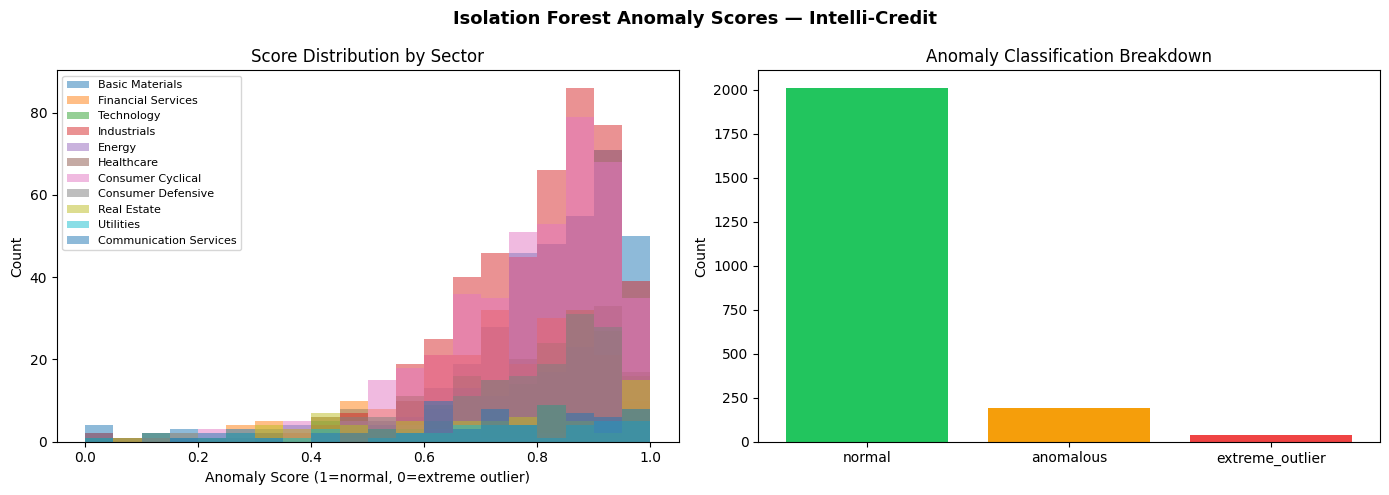


💾 Saved: isolation_forest_distribution.png

✅ Isolation Forest pipeline complete.

OUTPUT SUMMARY:
  computed_financial_ratios.csv    → Fills missing rulebook table
  isolation_forest_scores.csv     → Per-company anomaly scores
  peer_benchmark_narratives.csv   → Human-readable benchmark sentences
  iso_forest_{sector}.pkl        → Saved models for inference on new cases
 
FIVE Cs INTEGRATION:
  Capacity C ← anomaly_classification + DSCR/EBITDA percentile ranks
  Capital C  ← Debt/Equity percentile + net worth trend
  Conditions C ← peer performance benchmarks



In [ ]:
# ============================================================
# CELL 7: Visualization — Anomaly score distribution by sector
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Isolation Forest Anomaly Scores — Intelli-Credit", fontsize=13, fontweight="bold")

# Plot 1: Distribution by sector
for sector in iso_df["sector"].unique():
    subset = iso_df[iso_df["sector"] == sector]["anomaly_score_normalized"]
    axes[0].hist(subset, bins=20, alpha=0.5, label=sector)
axes[0].set_xlabel("Anomaly Score (1=normal, 0=extreme outlier)")
axes[0].set_ylabel("Count")
axes[0].set_title("Score Distribution by Sector")
axes[0].legend(fontsize=8)

# Plot 2: Anomaly classification breakdown
counts = iso_df["anomaly_classification"].value_counts()
axes[1].bar(counts.index, counts.values,
            color=["#22c55e", "#f59e0b", "#ef4444"])
axes[1].set_title("Anomaly Classification Breakdown")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig(str(OUTPUT_PATH / "isolation_forest_distribution.png"), dpi=150)
plt.show()
print(f"\n💾 Saved: isolation_forest_distribution.png")

print("\n✅ Isolation Forest pipeline complete.")
print(f"""
OUTPUT SUMMARY:
  computed_financial_ratios.csv    → Fills missing rulebook table
  isolation_forest_scores.csv     → Per-company anomaly scores
  peer_benchmark_narratives.csv   → Human-readable benchmark sentences
  iso_forest_{{sector}}.pkl        → Saved models for inference on new cases

FIVE Cs INTEGRATION:
  Capacity C ← anomaly_classification + DSCR/EBITDA percentile ranks
  Capital C  ← Debt/Equity percentile + net worth trend
  Conditions C ← peer performance benchmarks
""")


In [ ]:
print(iso_df.groupby("sector")["anomaly_classification"].value_counts())


sector                  anomaly_classification
Basic Materials         normal                    333
                        anomalous                  30
                        extreme_outlier             7
Communication Services  normal                     68
                        extreme_outlier             6
                        anomalous                   2
Consumer Cyclical       normal                    388
                        anomalous                  41
                        extreme_outlier             2
Consumer Defensive      normal                    144
                        anomalous                  14
                        extreme_outlier             2
Energy                  normal                     33
                        extreme_outlier             3
                        anomalous                   1
Financial Services      normal                    212
                        anomalous                  20
                        extreme_out